In [8]:
# Importación de librerías para manipulación y NLP
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Descarga de stopwords (solo se ejecuta la primera vez)
nltk.download('stopwords', quiet=True)

True

In [7]:
# Ajusta la ruta dependiendo de dónde tengas abierto tu Jupyter
# Según la estructura, los datos están en data/processed/
ruta_csv = '../data/processed/dataset_limpio.csv' 

# Cargamos el dataset
df = pd.read_csv(ruta_csv)

# Verificamos las columnas disponibles (para confirmar el nombre de la columna de texto y los tags)
print("Columnas disponibles:", df.columns.tolist())

# Seleccionamos un juego específico para hacer la prueba del NLP
nombre_juego_prueba = "Undertale" # Reemplaza con un juego real del dataset
df_juego = df[df['name'] == nombre_juego_prueba].copy()

print(f"Reseñas encontradas para {nombre_juego_prueba}: {len(df_juego)}")

Columnas disponibles: ['appid', 'name', 'release_date', 'required_age', 'price', 'dlc_count', 'detailed_description', 'about_the_game', 'short_description', 'reviews', 'header_image', 'website', 'support_url', 'support_email', 'windows', 'mac', 'linux', 'metacritic_score', 'metacritic_url', 'achievements', 'recommendations', 'notes', 'supported_languages', 'full_audio_languages', 'packages', 'developers', 'publishers', 'categories', 'genres', 'screenshots', 'movies', 'user_score', 'score_rank', 'positive', 'negative', 'estimated_owners', 'average_playtime_forever', 'average_playtime_2weeks', 'median_playtime_forever', 'median_playtime_2weeks', 'discount', 'peak_ccu', 'tags', 'pct_pos_total', 'num_reviews_total', 'pct_pos_recent', 'num_reviews_recent', 'reviews_limpias']
Reseñas encontradas para Undertale: 1


In [9]:
def limpiar_texto_prueba(texto):
    if not isinstance(texto, str):
        return ""
    
    # Todo a minúsculas y quitar caracteres raros/puntuación
    texto = texto.lower()
    texto = re.sub(r'[^\w\s]', '', texto)
    
    # Filtro de stopwords en inglés (asumiendo reseñas de Steam)
    stop_words = set(stopwords.words('english'))
    tokens = texto.split()
    tokens_limpios = [w for w in tokens if w not in stop_words]
    
    return " ".join(tokens_limpios)

# Aplicamos la limpieza
# IMPORTANTE: Reemplaza 'columna_reseñas' por el nombre real de tu captura
col_texto = 'reviews_limpias' 
df_juego['texto_limpio'] = df_juego[col_texto].apply(limpiar_texto_prueba)

# Vistazo rápido a cómo quedó el texto
df_juego[['texto_limpio']].head()

,texto_limpio
28,puzzles arent particularly impressive destruct...


In [10]:
# Convertimos la columna limpia a una lista de textos
textos = df_juego['texto_limpio'].dropna().tolist()

# Vectorización TF-IDF
vectorizer = TfidfVectorizer(max_features=500, stop_words='english')
tfidf_matrix = vectorizer.fit_transform(textos)

# Sumamos los scores de cada palabra
scores = tfidf_matrix.sum(axis=0).A1
palabras = vectorizer.get_feature_names_out()

# Armamos un DataFrame con los resultados
df_temas = pd.DataFrame({'Tema': palabras, 'Score': scores})
df_temas = df_temas.sort_values(by='Score', ascending=False).head(10)

print("--- Top 10 Temas Extraídos ---")
print(df_temas)

--- Top 10 Temas Extraídos ---
           Tema     Score
0         arent  0.229416
1        couple  0.229416
2     criticism  0.229416
3   destructoid  0.229416
4        doesnt  0.229416
5           fox  0.229416
6    impressive  0.229416
7     interface  0.229416
8        issues  0.229416
9  jimquisition  0.229416


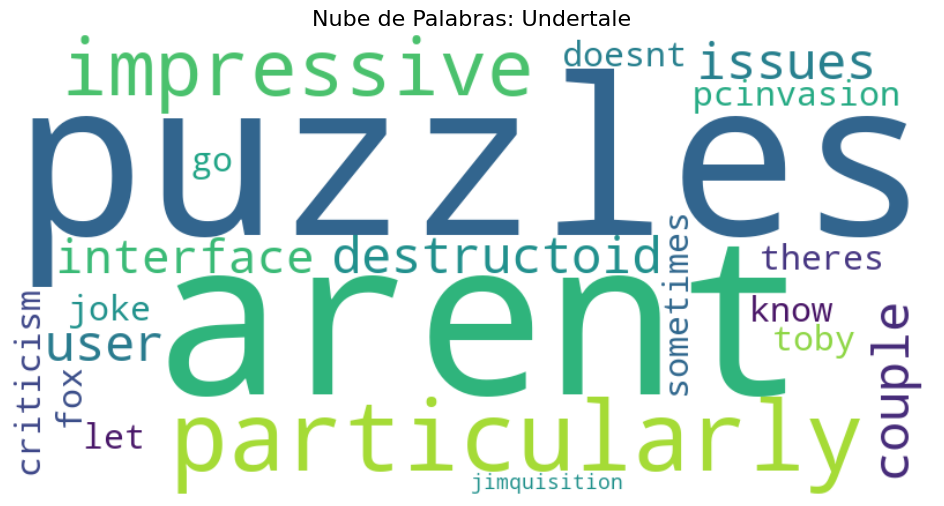

In [11]:
# Unir todo el texto limpio en un solo string
texto_completo = " ".join(textos)

# Configurar y generar la nube
wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white',
    colormap='viridis'
).generate(texto_completo)

# Mostrar la imagen
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title(f"Nube de Palabras: {nombre_juego_prueba}", fontsize=16)
plt.show()